# Data Analysis for SD-GPGPU2026 Submission, I - Overview



### Data Preparation

The data is taken from the Slack channel [silicon_mark](https://silicondata.slack.com/files/U09NQ432KSP/F0A4EBLQ7C4/siliconmark-provider-charts.zip).

Delete entries:
- GPU-0b8eb49d-d883-9cc1-aa43-749ef1afb730 is removed because it's way lower than the standard H100 PCIe.
- GPU-3369f751-3009-d274-8730-6484819eabb1 is removed because it's way lower than the standard A100 SXM4-80GB.



### Statistics by gpu_id

**Findings**
- Number of GPU ID: 3534
- Number of entries: 6809
- Number of GPUs occurring more than 3 (including 3) times: 736
- The maximum GPU fp16 range $(max - min)/mean$: 8.37%
- The maximum GPU d2d_bw range: 9.72%
- Percentage of GPUs with d2d_bw range <= 2%: 92.12%
- Percentage of GPUs with fp16 range <= 2%: 82.74%

**Conclusion**: The benchmark result is consistent.

In [2]:
%pip install pandas matplotlib seaborn scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df_raw = pd.read_csv('all_providers_data_2025-12-18.csv', sep=',')

Check if the gpu_id is same for different GPUs(different providers)

In [4]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        print(f"Different provider/gpu_model combinations for this gpu_id:")
        for i, data_row in gpu_data.iterrows():
            print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

Total number of gpu_ids: 3513
Number of gpu_ids with inconsistencies: 21

Detailed inconsistencies:

--- gpu_id #1: GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7 ---
Different provider/gpu_model combinations for this gpu_id:
  provider: lambda, gpu_model: NVIDIA A100-SXM4-80GB
  provider: paperspace, gpu_model: NVIDIA A100-SXM4-80GB

--- gpu_id #2: GPU-13af2717-7443-4f65-459d-49e4ad45578c ---
Different provider/gpu_model combinations for this gpu_id:
  provider: lambda, gpu_model: NVIDIA A100-SXM4-80GB
  provider: paperspace, gpu_model: NVIDIA A100-SXM4-80GB

--- gpu_id #3: GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c ---
Different provider/gpu_model combinations for this gpu_id:
  provider: lambda, gpu_model: NVIDIA A100-SXM4-80GB
  provider: paperspace, gpu_model: NVIDIA A100-SXM4-80GB

--- gpu_id #4: GPU-1b2bfb26-0030-7236-2a71-c51de359518f ---
Different provider/gpu_model combinations for this gpu_id:
  provider: lambda, gpu_model: NVIDIA A100-SXM4-80GB
  provider: paperspace, gpu_model: NV

In [5]:
# Check for gpu_model inconsistencies only
print("=" * 80)
print("Checking for GPU Model inconsistencies")
print("=" * 80)

# Find gpu_ids with gpu_model inconsistencies (gpu_model_count > 1)
only_gpu_model_inconsistent = gpu_id_groups[(gpu_id_groups['gpu_model_count'] > 1)]

print(f"\nNumber of gpu_ids with gpu_model inconsistencies: {len(only_gpu_model_inconsistent)}")

if len(only_gpu_model_inconsistent) > 0:
    print("\nDetailed inconsistencies:")
    for idx, (gpu_id, row) in enumerate(only_gpu_model_inconsistent.iterrows()):
        print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        print(f"Different provider/gpu_model combinations for this gpu_id:")
        for i, data_row in gpu_data.iterrows():
            print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("\nNo gpu_model inconsistencies found.")
    print("That is: No gpu_id corresponds to multiple different gpu_models.")

Checking for GPU Model inconsistencies

Number of gpu_ids with gpu_model inconsistencies: 0

No gpu_model inconsistencies found.
That is: No gpu_id corresponds to multiple different gpu_models.


In [6]:
# Add suffix "_1" to duplicate gpu_ids from different providers
# For gpu_ids that appear in multiple providers, add "_1" to non-first providers

def add_suffix_to_duplicate_gpu_ids(df):
    """
    For each gpu_id that appears in multiple providers,
    add "_1" suffix to gpu_ids from the second and subsequent providers.
    
    The first occurrence of each gpu_id keeps the original name.
    """
    df_modified = df.copy()
    
    # Find gpu_ids that appear with multiple providers
    gpu_id_providers = df_modified.groupby('gpu_id')['provider'].nunique()
    duplicate_gpu_ids = gpu_id_providers[gpu_id_providers > 1].index
    
    print(f"Total gpu_ids with multiple providers: {len(duplicate_gpu_ids)}")
    
    # For each duplicate gpu_id, mark which provider gets the suffix
    for gpu_id in duplicate_gpu_ids:
        mask = df_modified['gpu_id'] == gpu_id
        rows_with_gpu_id = df_modified[mask].copy()
        
        # Sort by provider to ensure consistent ordering
        rows_with_gpu_id = rows_with_gpu_id.sort_values('provider')
        providers_list = rows_with_gpu_id['provider'].unique()
        
        print(f"\ngpu_id: {gpu_id}")
        print(f"  Providers: {list(providers_list)}")
        
        # For each provider except the first, add "_1" suffix
        for idx, provider in enumerate(providers_list):
            if idx > 0:  # Skip the first provider
                # Find rows with this gpu_id and provider, and add suffix
                mask_for_suffix = (df_modified['gpu_id'] == gpu_id) & (df_modified['provider'] == provider)
                df_modified.loc[mask_for_suffix, 'gpu_id'] = gpu_id + '_1'
                print(f"    {provider}: gpu_id changed to {gpu_id}_1")
    
    return df_modified

# Apply the function
df_raw = add_suffix_to_duplicate_gpu_ids(df_raw)

print("\n" + "="*80)
print("Data processing completed!")
print(f"Original shape: {df_raw.shape}")
print(f"Processed shape: {df_raw.shape}")
print("\nSample of modified gpu_ids:")
print(df_raw[['provider', 'gpu_id', 'gpu_model']].drop_duplicates('gpu_id').head(25))

Total gpu_ids with multiple providers: 21

gpu_id: GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7_1

gpu_id: GPU-13af2717-7443-4f65-459d-49e4ad45578c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-13af2717-7443-4f65-459d-49e4ad45578c_1

gpu_id: GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c_1

gpu_id: GPU-1b2bfb26-0030-7236-2a71-c51de359518f
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1b2bfb26-0030-7236-2a71-c51de359518f_1

gpu_id: GPU-32af726d-bd07-4891-5852-6e7c56bdc16c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-32af726d-bd07-4891-5852-6e7c56bdc16c_1

gpu_id: GPU-3c5f1afe-253e-b0b0-b2df-4ff78533c043
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-3c5f1af

In [7]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        print(f"Different provider/gpu_model combinations for this gpu_id:")
        for i, data_row in gpu_data.iterrows():
            print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

Total number of gpu_ids: 3534
Number of gpu_ids with inconsistencies: 0

Detailed inconsistencies:
No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.


In [8]:
gpu_num = df_raw['gpu_id'].nunique()
print(f'The number of unique GPU id is: {gpu_num}')

gpu_id_counts = df_raw["gpu_id"].value_counts()

# gpu_id with the maximum occurrences
top_gpu_id = gpu_id_counts.idxmax()
top_gpu_count = gpu_id_counts.max()

print(f"GPU ID with the most occurrences: {top_gpu_id}")
print(f"Number of occurrences: {top_gpu_count}")

The number of unique GPU id is: 3534
GPU ID with the most occurrences: GPU-713b4618-fb55-60a6-c431-6c9fb26e6359
Number of occurrences: 12


The number of unique GPU id is: 3534
GPU ID with the most occurrences: GPU-713b4618-fb55-60a6-c431-6c9fb26e6359
Number of occurrences: 12

Find the GPUs occur more than 3 times. Calculate its fp16 max/avg, min/avg ratio spread and plot.

In [9]:
# --- Ensure numeric columns are numeric (coerce bad values to NaN) ---
for col in ["fp16", "memory_bandwidth"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")


In [10]:
# --- Filter gpu_ids with occurrences >= 3 ---
counts = df_raw["gpu_id"].value_counts()
valid_gpu_ids = counts[counts >= 3].index
df_filt = df_raw[df_raw["gpu_id"].isin(valid_gpu_ids)].copy()

# --- Aggregate fp16 stats per gpu_id ---
stats_fp16 = (
    df_filt.groupby("gpu_id")
    .agg(
        occurrences=("gpu_id", "count"),
        fp16_min=("fp16", "min"),
        fp16_max=("fp16", "max"),
        fp16_avg=("fp16", "mean"),
    )
    .reset_index()
)

# --- Compute derived ratios requested: max/avg and min/avg ---
stats_fp16["fp16_max_over_avg"] = stats_fp16["fp16_max"] / stats_fp16["fp16_avg"]
stats_fp16["fp16_min_over_avg"] = stats_fp16["fp16_min"] / stats_fp16["fp16_avg"]

# Optional rounding for display
stats_display_fp16 = stats_fp16.copy()
for c in ["fp16_min", "fp16_max", "fp16_avg", "fp16_max_over_avg", "fp16_min_over_avg"]:
    stats_display_fp16[c] = stats_display_fp16[c].round(4)

# Display table
# display("GPU IDs with occurrences > 3 and fp16 stats", stats_display_fp16)


In [11]:
# --- Aggregate fp16 stats per gpu_id ---
stats_bw = (
    df_filt.groupby("gpu_id")
    .agg(
        occurrences=("gpu_id", "count"),
        bw_min=("memory_bandwidth", "min"),
        bw_max=("memory_bandwidth", "max"),
        bw_avg=("memory_bandwidth", "mean"),
    )
    .reset_index()
)

# --- Compute derived ratios requested: max/avg and min/avg ---
stats_bw["bw_max_over_avg"] = stats_bw["bw_max"] / stats_bw["bw_avg"]
stats_bw["bw_min_over_avg"] = stats_bw["bw_min"] / stats_bw["bw_avg"]

# Optional rounding for display
# stats_display_bw = stats_bw.copy()
# for c in ["bw_min", "bw_max", "bw_avg", "bw_max_over_avg", "bw_min_over_avg"]:
#     stats_display_bw[c] = stats_display_bw[c].round(4)

stats_bw = stats_bw.sort_values(["gpu_id", "occurrences"], ascending=[True, True])

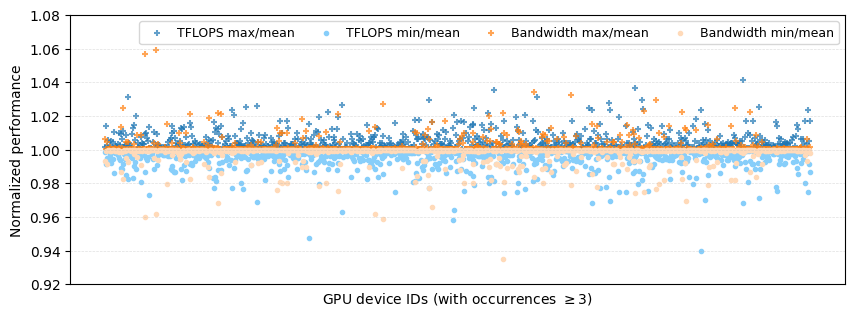

In [12]:

import matplotlib.pyplot as plt 
# Sort for more readable plot
stats_fp16 = stats_fp16.sort_values(["gpu_id", "occurrences"], ascending=[True, True])


plt.figure(figsize=(10, 3.5))
x = range(len(stats_fp16))
plt.scatter(x, stats_fp16["fp16_max_over_avg"],
            marker='+', color="tab:blue", s=20, alpha=0.7, label="TFLOPS max/mean")
plt.scatter(x, stats_fp16["fp16_min_over_avg"],
            marker='.', color="lightskyblue", label="TFLOPS min/mean")
plt.scatter(x, stats_bw["bw_max_over_avg"],
            marker='+', color="tab:orange", s=20, alpha=0.7, label="Bandwidth max/mean")
plt.scatter(x, stats_bw["bw_min_over_avg"],
            marker='.', color="peachpuff",label="Bandwidth min/mean")

# plt.xticks(x, stats_fp16["gpu_id"], rotation=90)
plt.ylabel("Normalized performance")
plt.xticks([])
plt.xlabel(r"GPU device IDs (with occurrences $\geq 3$)")

plt.legend(
    ncol=4,
    frameon=True,
    columnspacing=1.5,
    handletextpad=0.6,
    loc="best",
    fontsize=9,
)
plt.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)
plt.ylim(0.92, 1.08)


plt.savefig("all_gid_normalized.pdf", bbox_inches='tight', dpi=600)
plt.show()



In [13]:
stats_fp16["fp16_spread"] = (
    stats_fp16["fp16_max_over_avg"] - stats_fp16["fp16_min_over_avg"]
)

# Find maximum spread
max_spread_fp16 = stats_fp16["fp16_spread"].max()
max_spread_gpu_fp16 = stats_fp16.loc[
    stats_fp16["fp16_spread"].idxmax(), "gpu_id"
]

print(f"Maximum (max/avg - min/avg): {max_spread_fp16:.4f}")
print(f"GPU ID with maximum spread: {max_spread_gpu_fp16}")

# Optional: show the row
# display(stats_fp16.loc[stats_fp16["fp16_spread"].idxmax()])

Maximum (max/avg - min/avg): 0.0837
GPU ID with maximum spread: GPU-d9f92f86-3618-b33d-f280-3e40cb8523b8


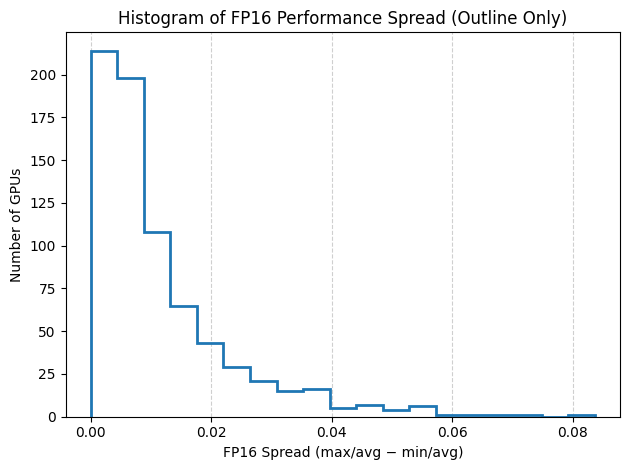

In [14]:
import numpy as np

spread_fp16 = stats_fp16["fp16_spread"].dropna()

# Define contiguous bins
bins = np.linspace(spread_fp16.min(), spread_fp16.max(), 20)

plt.figure()
plt.hist(
    spread_fp16,
    bins=bins,
    histtype="step",      # outline only
    linewidth=2
)

plt.xlabel("FP16 Spread (max/avg − min/avg)")
plt.ylabel("Number of GPUs")
plt.title("Histogram of FP16 Performance Spread (Outline Only)")
plt.tight_layout()
# Vertical grid lines only
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()


Maximum (max/avg - min/avg): 0.0972
GPU ID with maximum spread: GPU-1556b4f1-ae88-0270-037e-55840973fa3b


gpu_id             GPU-1556b4f1-ae88-0270-037e-55840973fa3b
occurrences                                               6
bw_min                                              2294.05
bw_max                                              2525.73
bw_avg                                              2384.59
bw_max_over_avg                                    1.059188
bw_min_over_avg                                    0.962031
bw_spread                                          0.097157
Name: 53, dtype: object

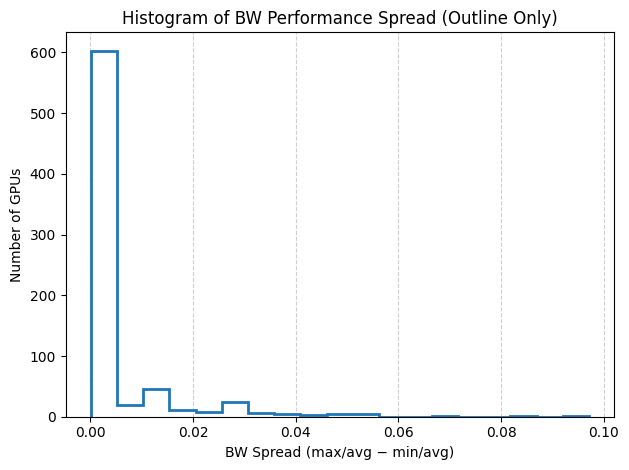

In [15]:
stats_bw["bw_spread"] = stats_bw["bw_max_over_avg"] - stats_bw["bw_min_over_avg"]
spread_bw = stats_bw["bw_spread"].dropna()
# Find maximum spread
max_spread_bw = stats_bw["bw_spread"].max()
max_spread_gpu = stats_bw.loc[
    stats_bw["bw_spread"].idxmax(), "gpu_id"
]

print(f"Maximum (max/avg - min/avg): {max_spread_bw:.4f}")
print(f"GPU ID with maximum spread: {max_spread_gpu}")

# Optional: show the row
display(stats_bw.loc[stats_bw["bw_spread"].idxmax()])

#-----
bins = np.linspace(spread_bw.min(), spread_bw.max(), 20)

plt.figure()
plt.hist(
    spread_bw,
    bins=bins,
    histtype="step",      # outline only
    linewidth=2
)

plt.xlabel("BW Spread (max/avg − min/avg)")
plt.ylabel("Number of GPUs")
plt.title("Histogram of BW Performance Spread (Outline Only)")
plt.tight_layout()
# Vertical grid lines only
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()


In [16]:
# Percentage of GPUs with spread <= 2%
threshold = 0.02
pct_under_2_fp16 = (stats_fp16["fp16_spread"] <= threshold).mean() * 100
pct_under_2_bw = (stats_bw["bw_spread"] <= threshold).mean() * 100
print(f"Percentage of GPUs with BW spread <= 2%: {pct_under_2_bw:.2f}%")
print(f"Percentage of GPUs with fp16 spread <= 2%: {pct_under_2_fp16:.2f}%")

Percentage of GPUs with BW spread <= 2%: 92.12%
Percentage of GPUs with fp16 spread <= 2%: 82.74%


### Statistics of GPU models per cloud provider

**Findings**: For A100 (PCIe/SXM), H100 (PCIe/SXM), and H200 GPUs, the FP16 matrix-multiplication throughput (TFLOPS) exhibits a narrower range, whereas the device-to-device (D2D) memory copy throughput (GB/s) shows a bimodal distribution concentrated toward the extremes.

In [17]:
gpu_model_counts = df_raw['gpu_model'].value_counts()
print(f"Number of unique GPU models: {gpu_model_counts.size}\n")

# for model, cnt in gpu_model_counts.items():
#     print(f"{model}: {cnt}")

summary = (
    df_raw
    .groupby('gpu_model', as_index=False)
    .agg(
        n_samples=('provider', 'size'),
        fp16_min=('fp16', 'min'),
        fp16_max=('fp16', 'max'),
        fp16_avg=('fp16', 'mean'),
        mem_bw_min=('memory_bandwidth', 'min'),
        mem_bw_max=('memory_bandwidth', 'max'),
        mem_bw_avg=('memory_bandwidth', 'mean'),
    )
)

# --- Add spread columns ---
summary['fp16_spread'] = (
     100 * (summary['fp16_max'] - summary['fp16_min']) / summary['fp16_avg']
)

summary['mem_bw_spread'] = (
    100 * (summary['mem_bw_max'] - summary['mem_bw_min']) / summary['mem_bw_avg']
)


# keep gpu models with >3 samples
summary = summary[summary['n_samples'] >= 3]

display(
    summary[['gpu_model', 'fp16_min', 'fp16_max', 'fp16_spread', 'mem_bw_min', 'mem_bw_max', 'mem_bw_spread', 'n_samples']]
    .round(3)
)


Number of unique GPU models: 13



,gpu_model,fp16_min,fp16_max,fp16_spread,mem_bw_min,mem_bw_max,mem_bw_spread,n_samples
1,NVIDIA A100 80GB PCIe,213.80,235.85,9.702,1521.01,1727.28,12.638,254
2,NVIDIA A100-PCIE-40GB,174.56,207.98,17.170,1383.05,1385.62,0.186,47
3,NVIDIA A100-SXM4-40GB,250.21,269.28,7.322,1379.17,1381.60,0.176,94
4,NVIDIA A100-SXM4-80GB,242.06,291.21,19.121,1458.62,1758.82,17.191,2096
5,NVIDIA A10G,67.68,69.35,2.416,481.85,488.61,1.386,940
6,NVIDIA H100 80GB HBM3,648.52,719.80,10.398,2543.86,3026.97,16.671,452
7,NVIDIA H100 NVL,280.73,318.93,12.652,2269.38,2797.87,21.470,302
8,NVIDIA H100 PCIe,296.24,424.39,34.486,1655.08,1837.31,10.077,259
9,NVIDIA H200,634.66,681.70,7.124,2939.47,4212.67,37.822,253
10,NVIDIA L4,48.74,56.91,15.432,231.49,238.87,3.100,1170


In [18]:

provider_counts = df_raw['provider'].value_counts()
print(f"Number of unique providers: {provider_counts.size}\n")

for provider, cnt in sorted(provider_counts.items()):
    print(f"{provider}: {cnt}")

Number of unique providers: 14

aws: 3050
boostrun: 16
crusoe: 40
datacrunch: 234
digitalocean: 2
gcp: 127
hyperstack: 2
imwt: 2
lambda: 1897
latitude: 1
massedcompute: 2
nebius: 24
paperspace: 32
runpod: 1379


Number of unique GPU models: 13
- NVIDIA A100-SXM4-80GB: 2096
- NVIDIA L4: 1170
- NVIDIA A10G: 940
- Tesla T4: 939
- NVIDIA H100 80GB HBM3: 452
- NVIDIA H100 NVL: 303
- NVIDIA H100 PCIe: 260
- NVIDIA A100 80GB PCIe: 254
- NVIDIA H200: 253
- NVIDIA A100-SXM4-40GB: 94
- NVIDIA A100-PCIE-40GB: 47
- NVIDIA L40S: 1
- AMD Instinct MI300X VF: 1

Number of unique providers: 14
- aws: 3050
- boostrun: 16
- crusoe: 40
- datacrunch: 234
- digitalocean: 2
- gcp: 127
- hyperstack: 2
- imwt: 2
- lambda: 1897
- latitude: 1
- massedcompute: 2
- nebius: 24
- paperspace: 32
- runpod: 1381

For the below analysis, we target at the cloud providers with more than 10 data samples.

In [19]:
# --- Create a cloud provider anonymous dictionary for the target cloud providers ---
provider_anon_dict = {
    'aws': 'Cld-1',
    'gcp': 'Cld-5',
    'boostrun': 'Cld-2',
    'crusoe': 'Cld-3',
    'datacrunch': 'Cld-4',
    'lambda': 'Cld-6',
    'massedcompute': 'Cld-9',
    'nebius': 'Cld-7',
    'paperspace': 'Cld-8',
    'runpod': 'Cld-9'
}

In [20]:
# --- Keep only A100 / H100 / H200 ---
mask = df_raw['gpu_model'].str.contains(r'A100|H100|H200', regex=True)
df_nv_dc = df_raw.loc[mask].copy()

display(df_nv_dc['gpu_model'].value_counts().sort_index())
gpu_family_list = [_ for _ in sorted(df_nv_dc['gpu_model'].unique())]
print(f"GPU families considered: {gpu_family_list}")
print(f"Number of GPU families considered: {len(gpu_family_list)}")

gpu_model
NVIDIA A100 80GB PCIe     254
NVIDIA A100-PCIE-40GB      47
NVIDIA A100-SXM4-40GB      94
NVIDIA A100-SXM4-80GB    2096
NVIDIA H100 80GB HBM3     452
NVIDIA H100 NVL           302
NVIDIA H100 PCIe          259
NVIDIA H200               253
Name: count, dtype: int64

GPU families considered: ['NVIDIA A100 80GB PCIe', 'NVIDIA A100-PCIE-40GB', 'NVIDIA A100-SXM4-40GB', 'NVIDIA A100-SXM4-80GB', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 NVL', 'NVIDIA H100 PCIe', 'NVIDIA H200']
Number of GPU families considered: 8


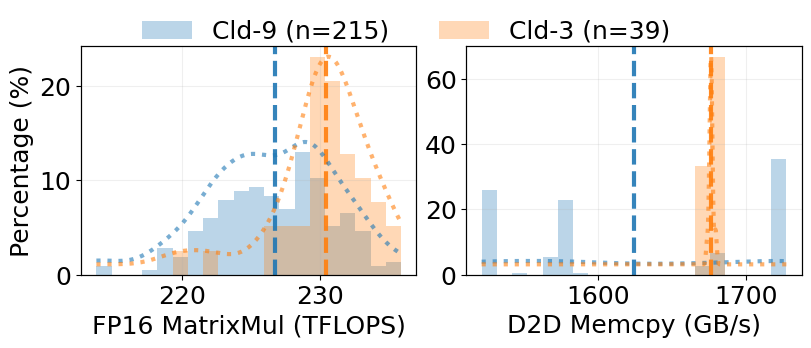

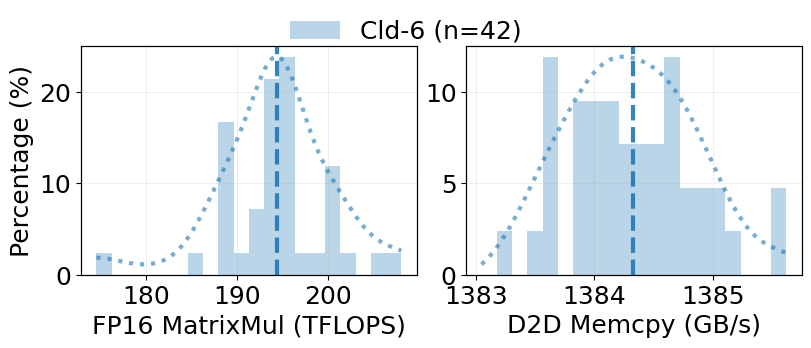

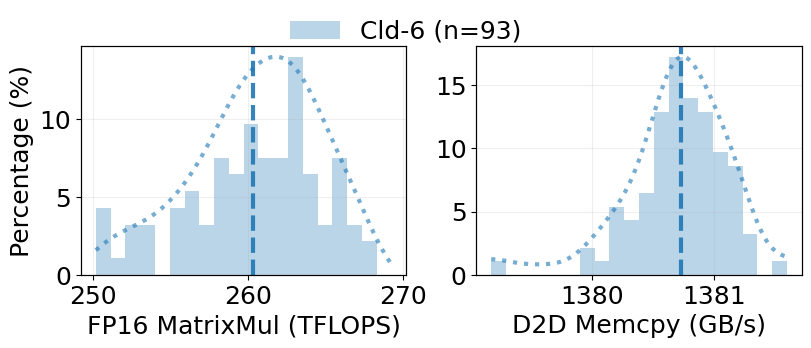

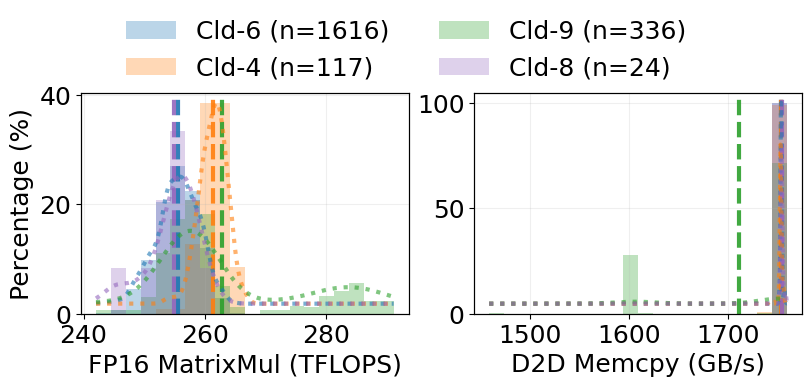

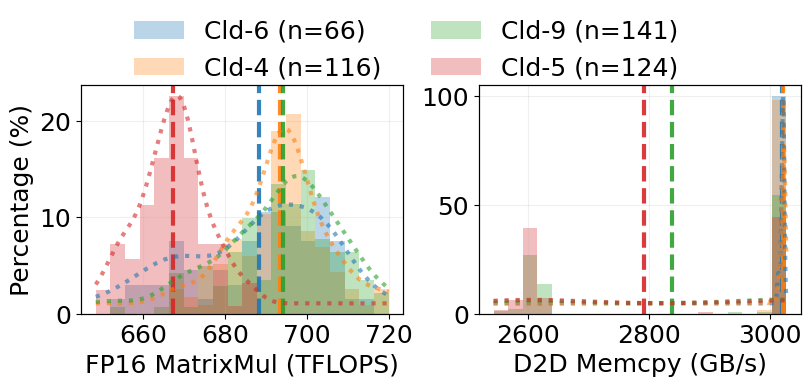

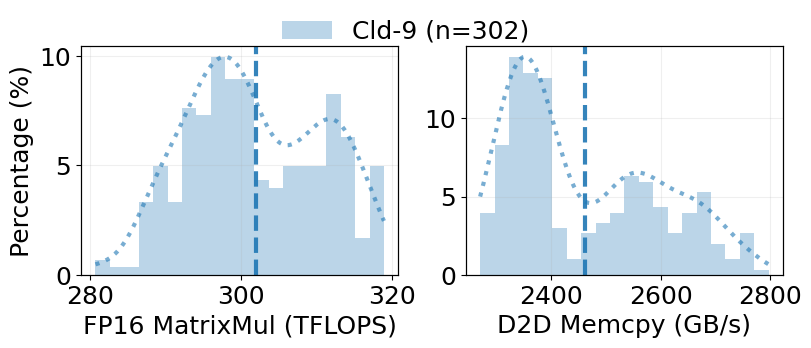

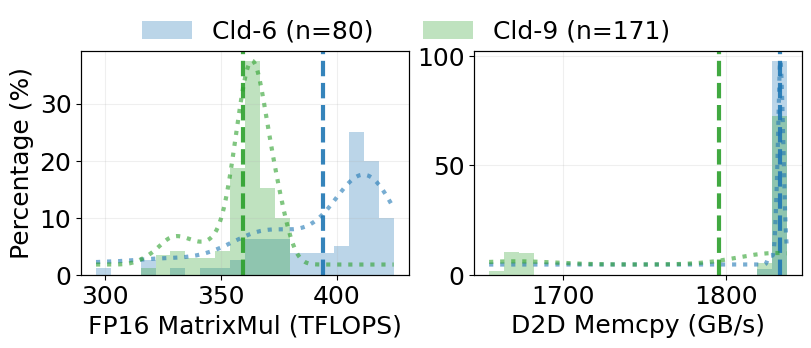

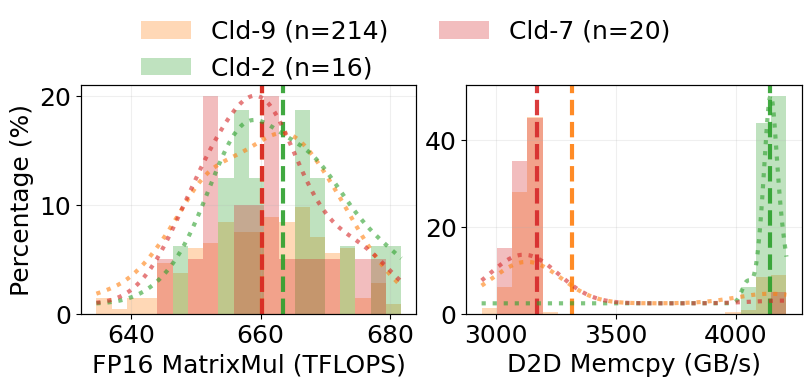

In [45]:
from scipy import stats


NUM_BINS = 20
colors = plt.cm.tab10.colors

# --- A total of 8 GPU models are considered ---
nrows, ncols = 1, 2
for gpu_model in gpu_family_list:
    
    df_target = df_nv_dc[df_nv_dc['gpu_model'] == gpu_model]
    providers = df_target['provider'].dropna().unique()

    fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3), constrained_layout=True)
    axes = axes.flatten()

    for id_plot, metric in enumerate(['fp16', 'memory_bandwidth']):
        ax = axes[id_plot]
        ax_hist = ax
        ax_kde = ax_hist.twinx()

        # Global fixed bins for consistent histogram widths within this subplot
        global_min = df_target[metric].min()
        global_max = df_target[metric].max()
        bin_edges = np.linspace(global_min, global_max, NUM_BINS + 1)

        for i, provider in enumerate(providers):
            vals = df_target.loc[df_target['provider'] == provider, metric].dropna().values
            if len(vals) < 10:
                continue
            
            # Histogram weights  
            N = len(vals)
            weights = 100 * np.ones_like(vals) / N   # for percentage histogram
            ax_hist.hist(
                vals, bins=bin_edges, alpha=0.3,
                density=False, weights=weights,
                color=colors[i],
                histtype='stepfilled',
                # edgecolor=colors[i],   # outline color
                linewidth=1,         # outline thickness
                label=f'{provider_anon_dict.get(provider, provider)} (n={len(vals)})'
            )
            
            # Add mean line for this provider
            mean_val = vals.mean()
            ax.axvline(mean_val, color=colors[i], linestyle='--', alpha=0.9,
                    linewidth=3)

            # Add a KDE curve
            # if metric == 'memory_bandwidth':
            #     continue
            kde = stats.gaussian_kde(vals)
            x_range = np.linspace(global_min, global_max, 1000)
            kde_values = kde(x_range)
            ax_kde.plot(x_range, kde_values, linewidth=3,
                        linestyle=':', color=colors[i], alpha=0.6)

        if metric == 'fp16':
            ax.set_xlabel("FP16 MatrixMul (TFLOPS)", fontsize=18)
            ax_hist.set_ylabel("Percentage (%)", fontsize=18)
        else:
            ax.set_xlabel("D2D Memcpy (GB/s)", fontsize=18)
       
        ax_kde.set_ylabel("")
        ax_kde.tick_params(axis='y', right=False, labelright=False)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(True, alpha=0.2)

    # Single shared legend centered at the top of the figure
    handles, labels = axes[0].get_legend_handles_labels()
    # Adjust legend position based on number of rows (2 cols max)
    legend_y = 1.28 if len(handles) > 2 else 1.15
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, legend_y),
               ncol=min(len(handles), 2), fontsize=18, frameon=False)

    plt.savefig(f'{gpu_model.replace(" ", "_")}_providers.pdf', dpi=600, bbox_inches='tight')
    plt.show()

In the above figures, we can exclude the ones with only one cloud providers. This leaves only 5 GPU models.

In [22]:
gpu_keep = [
    'NVIDIA A100 80GB PCIe',
    'NVIDIA A100-SXM4-80GB',
    'NVIDIA H100 PCIe',
    'NVIDIA H100 80GB HBM3',
    'NVIDIA H200',
]

# --- Filter to selected GPU models ---
df_filt = df_raw[df_raw['gpu_model'].isin(gpu_keep)].copy()
NSAMPLES_THRESHOLD = 10

# --- Group by gpu_model + provider and compute stats ---
summary = (
    df_filt
    .groupby(['gpu_model', 'provider'], as_index=False)
    .agg(
        n_samples=('provider', 'size'),
        fp16_min=('fp16', 'min'),
        fp16_max=('fp16', 'max'),
        fp16_avg=('fp16', 'mean'),
        mem_bw_min=('memory_bandwidth', 'min'),
        mem_bw_max=('memory_bandwidth', 'max'),
        mem_bw_avg=('memory_bandwidth', 'mean'),
    )
    .assign(
        fp16_norm_range=lambda d: 100 * (d.fp16_max - d.fp16_min) / d.fp16_avg,
        mem_bw_norm_range=lambda d: 100 * (d.mem_bw_max - d.mem_bw_min) / d.mem_bw_avg,
    )
)

# --- Filter out providers with small sample counts ---
summary = summary[summary['n_samples'] >= NSAMPLES_THRESHOLD]

display(summary.round(2))

print(f"Number of (gpu_model, provider) groups after filtering: {len(summary)}")


,gpu_model,provider,n_samples,fp16_min,fp16_max,fp16_avg,mem_bw_min,mem_bw_max,mem_bw_avg,fp16_norm_range,mem_bw_norm_range
0,NVIDIA A100 80GB PCIe,crusoe,39,219.67,235.51,230.38,1673.41,1679.91,1676.37,6.88,0.39
1,NVIDIA A100 80GB PCIe,runpod,215,213.80,235.85,226.70,1521.01,1727.28,1624.14,9.73,12.70
2,NVIDIA A100-SXM4-80GB,datacrunch,117,253.94,266.37,261.39,1740.97,1756.13,1752.67,4.76,0.86
4,NVIDIA A100-SXM4-80GB,lambda,1616,242.79,265.05,255.55,1749.84,1758.82,1753.35,8.71,0.51
5,NVIDIA A100-SXM4-80GB,paperspace,24,244.70,260.46,254.89,1752.31,1757.70,1753.77,6.18,0.31
6,NVIDIA A100-SXM4-80GB,runpod,336,242.06,291.21,262.83,1458.62,1758.07,1710.60,18.70,17.51
7,NVIDIA H100 80GB HBM3,datacrunch,116,666.50,719.46,693.33,2993.17,3026.97,3021.30,7.64,1.12
8,NVIDIA H100 80GB HBM3,gcp,124,648.52,686.38,667.25,2567.44,3025.52,2792.92,5.67,16.40
9,NVIDIA H100 80GB HBM3,lambda,66,653.49,715.13,688.33,3012.05,3025.27,3020.63,8.96,0.44
12,NVIDIA H100 80GB HBM3,runpod,141,653.27,719.80,694.21,2543.86,3025.05,2838.59,9.58,16.95


Number of (gpu_model, provider) groups after filtering: 15


In [23]:
# --- Inter-provider normalized range (per GPU model) ---
# Definition: first collapse to a provider-level representative value (mean), then
# compute normalized range across providers: (max - min) / mean.

# --- Group by gpu_model + provider and compute stats ---
summary = (
    df_filt
    .groupby(['gpu_model'], as_index=False)
    .agg(
        n_samples=('gpu_model', 'size'),
        fp16_min=('fp16', 'min'),
        fp16_max=('fp16', 'max'),
        fp16_avg=('fp16', 'mean'),
        mem_bw_min=('memory_bandwidth', 'min'),
        mem_bw_max=('memory_bandwidth', 'max'),
        mem_bw_avg=('memory_bandwidth', 'mean'),
    )
    .assign(
        fp16_norm_range=lambda d: 100 * (d.fp16_max - d.fp16_min) / d.fp16_avg,
        mem_bw_norm_range=lambda d: 100 * (d.mem_bw_max - d.mem_bw_min) / d.mem_bw_avg,
    )
)

# --- Filter out providers with small sample counts ---
summary = summary[summary['n_samples'] >= NSAMPLES_THRESHOLD]

display(summary.round(2))


,gpu_model,n_samples,fp16_min,fp16_max,fp16_avg,mem_bw_min,mem_bw_max,mem_bw_avg,fp16_norm_range,mem_bw_norm_range
0,NVIDIA A100 80GB PCIe,254,213.80,235.85,227.26,1521.01,1727.28,1632.16,9.70,12.64
1,NVIDIA A100-SXM4-80GB,2096,242.06,291.21,257.04,1458.62,1758.82,1746.25,19.12,17.19
2,NVIDIA H100 80GB HBM3,452,648.52,719.80,685.50,2543.86,3026.97,2897.89,10.40,16.67
3,NVIDIA H100 PCIe,259,296.24,424.39,371.60,1655.08,1837.31,1808.46,34.49,10.08
4,NVIDIA H200,253,634.66,681.70,660.34,2939.47,4212.67,3366.29,7.12,37.82
